# 3-way Blender — XGBoost + LightGBM + CatBoost

Loads OOFs from all three models, finds the optimal convex combination via 2D simplex grid search, applies the same weights to the test predictions, and saves a submission.

**Run order:** `xgboost.ipynb` + `lightgbm.ipynb` + `catboost.ipynb` first, then this notebook.

**Diversity context:** XGB↔LGBM correlate at 0.99 (same inductive bias), but CatBoost↔GBMs correlate at ~0.96 — that's the gap blending exploits.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.figsize'] = (10, 5)

from sklearn.metrics import roc_auc_score
from common import find_next_submission_file, find_last_submission_file

## Load OOFs

In [2]:
xgb_oof_df  = pd.read_csv('./archive/xgb_oof.csv')
lgbm_oof_df = pd.read_csv('./archive/lgbm_oof.csv')
cat_oof_df  = pd.read_csv('./archive/catboost_oof.csv')

assert len(xgb_oof_df) == len(lgbm_oof_df) == len(cat_oof_df), 'OOF lengths mismatch'
assert np.array_equal(xgb_oof_df['y'].values, lgbm_oof_df['y'].values), 'XGB/LGBM labels mismatch'
assert np.array_equal(xgb_oof_df['y'].values, cat_oof_df['y'].values),  'XGB/Cat labels mismatch'

y_oof    = xgb_oof_df['y'].values
xgb_oof  = xgb_oof_df['oof'].values
lgbm_oof = lgbm_oof_df['oof'].values
cat_oof  = cat_oof_df['oof'].values

print(f'rows: {len(y_oof)}')
print(f'XGB  OOF AUC: {roc_auc_score(y_oof, xgb_oof):.5f}')
print(f'LGBM OOF AUC: {roc_auc_score(y_oof, lgbm_oof):.5f}')
print(f'CAT  OOF AUC: {roc_auc_score(y_oof, cat_oof):.5f}')
print()
print(f'XGB ↔ LGBM corr: {np.corrcoef(xgb_oof, lgbm_oof)[0,1]:.4f}')
print(f'XGB ↔ CAT  corr: {np.corrcoef(xgb_oof, cat_oof )[0,1]:.4f}')
print(f'LGBM ↔ CAT corr: {np.corrcoef(lgbm_oof, cat_oof)[0,1]:.4f}')

rows: 439140
XGB  OOF AUC: 0.93514
LGBM OOF AUC: 0.93522
CAT  OOF AUC: 0.93130

XGB ↔ LGBM corr: 0.9907
XGB ↔ CAT  corr: 0.9571
LGBM ↔ CAT corr: 0.9650


## Search the simplex

Grid over `(w_xgb, w_lgbm)` with step 0.01; `w_cat = 1 - w_xgb - w_lgbm`, constrained ≥ 0. ~5000 points, AUC on 439k rows each — about a minute.

In [3]:
STEP = 0.01
best_auc = -np.inf
best_w = None
results = []

for w1 in np.arange(0.0, 1.0 + STEP/2, STEP):
    for w2 in np.arange(0.0, 1.0 - w1 + STEP/2, STEP):
        w3 = 1.0 - w1 - w2
        if w3 < -1e-9:
            continue
        w3 = max(0.0, w3)
        blend = w1 * xgb_oof + w2 * lgbm_oof + w3 * cat_oof
        auc = roc_auc_score(y_oof, blend)
        results.append((w1, w2, w3, auc))
        if auc > best_auc:
            best_auc = auc
            best_w = (w1, w2, w3)

print(f'best weights: XGB={best_w[0]:.2f}  LGBM={best_w[1]:.2f}  CAT={best_w[2]:.2f}')
print(f'best OOF AUC: {best_auc:.5f}')

# Compare to references
best_single = max(roc_auc_score(y_oof, xgb_oof), roc_auc_score(y_oof, lgbm_oof), roc_auc_score(y_oof, cat_oof))
print(f'\nvs best single model: {best_auc - best_single:+.5f}')
print(f'vs equal-weight 1/3:  {best_auc - roc_auc_score(y_oof, (xgb_oof + lgbm_oof + cat_oof)/3):+.5f}')

# also report the best 2-way (XGB+LGBM only) for direct comparison to the old blender
alphas = np.linspace(0, 1, 101)
twoway = [roc_auc_score(y_oof, a*xgb_oof + (1-a)*lgbm_oof) for a in alphas]
print(f'best 2-way (XGB+LGBM only): {max(twoway):.5f} at alpha={alphas[int(np.argmax(twoway))]:.2f}')

best weights: XGB=0.52  LGBM=0.21  CAT=0.27
best OOF AUC: 0.93645

vs best single model: +0.00124
vs equal-weight 1/3:  +0.00011
best 2-way (XGB+LGBM only): 0.93580 at alpha=0.49


## Visualize the simplex

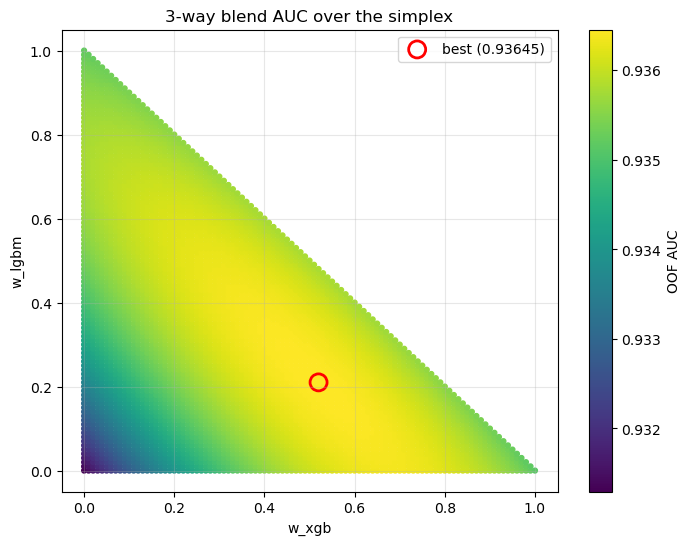

In [4]:
# Show AUC as a triangle scatter (w_xgb, w_lgbm) with color = AUC.
import matplotlib
res = np.array(results)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(res[:, 0], res[:, 1], c=res[:, 3], cmap='viridis', s=12)
ax.scatter([best_w[0]], [best_w[1]], facecolor='none', edgecolor='red', s=150, lw=2, label=f'best ({best_auc:.5f})')
ax.set_xlabel('w_xgb'); ax.set_ylabel('w_lgbm')
ax.set_title('3-way blend AUC over the simplex')
ax.legend()
plt.colorbar(sc, label='OOF AUC')
plt.grid(alpha=0.3)
plt.show()

## Build the test-set blend with the same weights

In [5]:
xgb_test_df  = pd.read_csv('./archive/xgb_test.csv')
lgbm_test_df = pd.read_csv('./archive/lgbm_test.csv')
cat_test_df  = pd.read_csv('./archive/catboost_test.csv')

assert len(xgb_test_df) == len(lgbm_test_df) == len(cat_test_df), 'test lengths mismatch'
assert np.array_equal(xgb_test_df['id'].values, lgbm_test_df['id'].values), 'XGB/LGBM ids mismatch'
assert np.array_equal(xgb_test_df['id'].values, cat_test_df['id'].values),  'XGB/Cat ids mismatch'

w1, w2, w3 = best_w
blended = w1 * xgb_test_df['pred'].values + w2 * lgbm_test_df['pred'].values + w3 * cat_test_df['pred'].values

submission_df = pd.DataFrame({'id': xgb_test_df['id'].values, 'PitNextLap': blended})
print(submission_df.head())
print()
print(submission_df['PitNextLap'].describe())

       id  PitNextLap
0  439140    0.005551
1  439141    0.005490
2  439142    0.005027
3  439143    0.188331
4  439144    0.890827

count    188165.000000
mean          0.197532
std           0.300147
min           0.000057
25%           0.003058
50%           0.020396
75%           0.311860
max           0.993210
Name: PitNextLap, dtype: float64


## Save submission

In [6]:
from glob import glob
existing_subs = sorted(glob('./archive/submission_*.csv'))
last_submission = pd.read_csv(existing_subs[-1]) if existing_subs else None

if (
    last_submission is not None
    and 'PitNextLap' in last_submission.columns
    and len(last_submission) == len(submission_df)
    and np.allclose(last_submission['PitNextLap'], submission_df['PitNextLap'], rtol=1e-5)
):
    print('skipping save (identical to last submission)')
else:
    out = find_next_submission_file() if last_submission is not None else './archive/submission_01.csv'
    submission_df.to_csv(out, index=False)
    print(f'saved {out}')

saved ./archive/submission_28.csv
